# Case B — Weather & Alcohol Sales (DEAD)

**Client:** Drinking Excess Alcohol is Dangerous (DEAD) — a nonprofit
working to make alcohol culture safer in Iowa. They want to understand what
factors drive higher or lower alcohol purchases; this notebook tests their
current hypothesis: **does weather drive alcohol purchases?**

This notebook picks up **after** the data build step — it assumes
`liquor_category_month_agg.parquet` (and `liquor_2022_2026.parquet`, used
for one date lookup below) already exist. Run `caseb_build_data.ipynb`
first if they don't, or if the underlying data has changed. Nothing here
re-downloads or re-parses the raw JSON.

In [10]:
import io

import duckdb as db
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
import statsmodels.api as sm

con = db.connect()

df = pd.read_parquet("liquor_category_month_agg.parquet")
print(df.shape)
df.head()

(2474, 15)


,category_name,year_month,year,month_num,total_units,total_dollars,total_liters,avg_bottle_price,realized_price_per_unit,n_stores,n_zips_reached,n_transactions,log_units,log_dollars,log_liters
0,,2026-06,2026,6,1158.0,52098.42,868.50,44.99,44.990000,19,17,19,7.055313,10.860909,6.767918
1,,2026-07,2026,7,336.0,15116.64,252.00,44.99,44.990000,6,5,10,5.820083,9.623618,5.533389
2,,2026-08,2026,8,240.0,10797.60,180.00,44.99,44.990000,1,1,2,5.484797,9.287172,5.198497
3,100% AGAVE TEQUILA,2022-01,2022,1,50549.0,1443274.89,34750.75,NaN,28.551997,885,271,5596,10.830718,14.182426,10.455985
4,100% AGAVE TEQUILA,2022-02,2022,2,63393.0,1927074.55,43229.90,NaN,30.398854,1004,281,6848,11.057124,14.471514,10.674311


## Weather (statewide, monthly) — testing the DEAD hypothesis

DEAD's question is what drives higher/lower alcohol purchases, and the
hypothesis on the table is **weather**. The observational unit built above
is *category x year-month*, statewide — there's no store/zip dimension left
at this grain — so weather needs to come in as a single **statewide monthly
weather series**, not the per-zip join used in `final_eda.ipynb` (that join
is the right one for transaction-level work; this notebook's grain is
coarser on purpose, for the regression setup below).

**Design decision, up front, because it changes what the regression can
actually tell DEAD:** `model_df` above already has a month-of-year dummy
for every calendar month, to soak up seasonality. Average temperature *is*
essentially a deterministic function of calendar month — January is cold
and July is warm every year — so if we hand the regression both "month =
July" and "average temp = 83°F" as separate predictors, they're almost
perfectly collinear and the model can't tell you which one is doing the
work. That's not really the question DEAD is asking anyway: "it's warmer
in summer" isn't an actionable weather finding, it's just seasonality
restated.

The more useful (and more rigorous) test is whether a given month's weather
being **unusual for that month** predicts sales being unusual for that
month — i.e. was this particular July hotter or wetter than a typical July,
and did that July sell more or less alcohol than a typical July. The IEM
daily feed conveniently ships a `climo_high_f` / `climo_low_f` /
`climo_precip_in` column alongside every observation — the NOAA long-run
climate normal for that station and calendar date — so the anomaly
(actual minus normal) is available directly rather than needing to be
estimated from this dataset's own 5 years of history.

Both cuts are fit below: a simpler model using raw weather levels (no month
fixed effects -- weather is left to explain seasonality itself), and the
anomaly model (with month fixed effects -- the rigorous test of whether
weather matters *beyond* time of year).

In [11]:
def get_iowa_asos_stations():
    """Iowa ASOS station metadata (id, lat/lon, online status)."""
    url = "https://mesonet.agron.iastate.edu/geojson/network/IA_ASOS.geojson"
    data = requests.get(url, timeout=30).json()

    rows = []
    for feat in data["features"]:
        props = feat["properties"]
        rows.append({"station": props["sid"], "online": props["online"]})

    stations_df = pd.DataFrame(rows)
    return stations_df[stations_df["online"]].reset_index(drop=True)


def fetch_iem_daily_weather(stations, start_date, end_date, network="IA_ASOS"):
    """Fetch daily weather summaries (incl. NOAA climate-normal columns) from IEM."""
    start_date = pd.Timestamp(start_date)
    end_date = pd.Timestamp(end_date)

    url = "https://mesonet.agron.iastate.edu/cgi-bin/request/daily.py"
    params = {
        "network": network,
        "stations": ",".join(sorted(set(stations))),
        "year1": start_date.year, "month1": start_date.month, "day1": start_date.day,
        "year2": end_date.year, "month2": end_date.month, "day2": end_date.day,
        "format": "csv",
    }

    resp = requests.get(url, params=params, timeout=180)
    resp.raise_for_status()

    weather_df = pd.read_csv(io.StringIO(resp.text))
    weather_df["day"] = pd.to_datetime(weather_df["day"])
    return weather_df


stations_df = get_iowa_asos_stations()

start_date = df["year_month"].min() + "-01"
# last full or partial month present in the panel -- use the actual max ordered_on
# from the source table so we don't ask IEM for dates that don't exist yet
end_date = con.execute("SELECT MAX(ordered_on) FROM 'liquor_2022_2026.parquet'").fetchone()[0]

station_weather = fetch_iem_daily_weather(stations_df["station"], start_date, end_date)
print(station_weather.shape, station_weather["day"].min(), station_weather["day"].max())
station_weather.head()

(103944, 23) 2022-01-01 00:00:00 2026-08-31 00:00:00


,station,day,max_temp_f,min_temp_f,max_dewpoint_f,min_dewpoint_f,precip_in,avg_wind_speed_kts,avg_wind_drct,min_rh,...,snowd_in,min_feel,avg_feel,max_feel,max_wind_speed_kts,max_wind_gust_kts,srad_mj,climo_high_f,climo_low_f,climo_precip_in
0,CNC,2022-01-01,17.6,1.4,17.6,-2.2,NaN,16.494774,353.236800,84.431350,...,NaN,-18.280874,-12.602345,1.210419,21.0,29.000000,NaN,32.3,12.3,0.03
1,AWG,2022-01-01,28.4,6.8,28.4,6.8,NaN,15.885017,354.219600,100.000000,...,NaN,-11.889464,-1.302507,18.453651,21.0,27.000000,NaN,31.0,13.8,0.04
2,CID,2022-01-01,18.0,3.0,15.1,1.0,0.06,16.546340,355.694000,87.204025,...,NaN,-17.380530,-9.320206,2.630232,22.0,29.545193,NaN,28.9,13.0,0.04
3,BRL,2022-01-01,30.0,12.0,28.0,7.0,0.54,14.150522,357.757200,79.932470,...,NaN,-4.617557,7.158616,20.460064,21.0,33.021100,NaN,32.8,16.8,0.06
4,AIO,2022-01-01,8.6,-0.4,8.6,-9.4,0.00,16.285715,7.683314,64.877870,...,NaN,-21.503796,-17.105019,-9.555942,22.0,28.000000,NaN,32.0,11.5,0.03


In [12]:
# statewide daily average across every reporting station that day
statewide_daily = station_weather.groupby("day").agg(
    avg_max_temp_f=("max_temp_f", "mean"),
    avg_min_temp_f=("min_temp_f", "mean"),
    precip_in=("precip_in", "mean"),
    snow_in=("snow_in", "mean"),
    climo_high_f=("climo_high_f", "mean"),
    climo_precip_in=("climo_precip_in", "mean"),
).reset_index()

statewide_daily["temp_anomaly_f"] = statewide_daily["avg_max_temp_f"] - statewide_daily["climo_high_f"]
statewide_daily["precip_anomaly_in"] = statewide_daily["precip_in"] - statewide_daily["climo_precip_in"]

statewide_daily["year_month"] = statewide_daily["day"].dt.strftime("%Y-%m")

monthly_weather = statewide_daily.groupby("year_month").agg(
    avg_max_temp_f=("avg_max_temp_f", "mean"),
    avg_min_temp_f=("avg_min_temp_f", "mean"),
    total_precip_in=("precip_in", "sum"),
    total_snow_in=("snow_in", "sum"),
    avg_temp_anomaly_f=("temp_anomaly_f", "mean"),
    total_precip_anomaly_in=("precip_anomaly_in", "sum"),
).reset_index()

print(monthly_weather.shape)
monthly_weather.head()

(56, 7)


,year_month,avg_max_temp_f,avg_min_temp_f,total_precip_in,total_snow_in,avg_temp_anomaly_f,total_precip_anomaly_in
0,2022-01,27.556750,5.741260,0.428410,9.497544,-1.219189,-0.582902
1,2022-02,34.396990,10.519846,0.408517,3.708449,0.828196,-0.837876
2,2022-03,47.475857,27.976173,2.618019,3.768596,0.625037,0.558838
3,2022-04,56.243190,34.801492,3.400219,1.305020,-4.318887,-0.310765
4,2022-05,72.767502,52.576101,3.479729,0.000007,1.299073,-1.416500


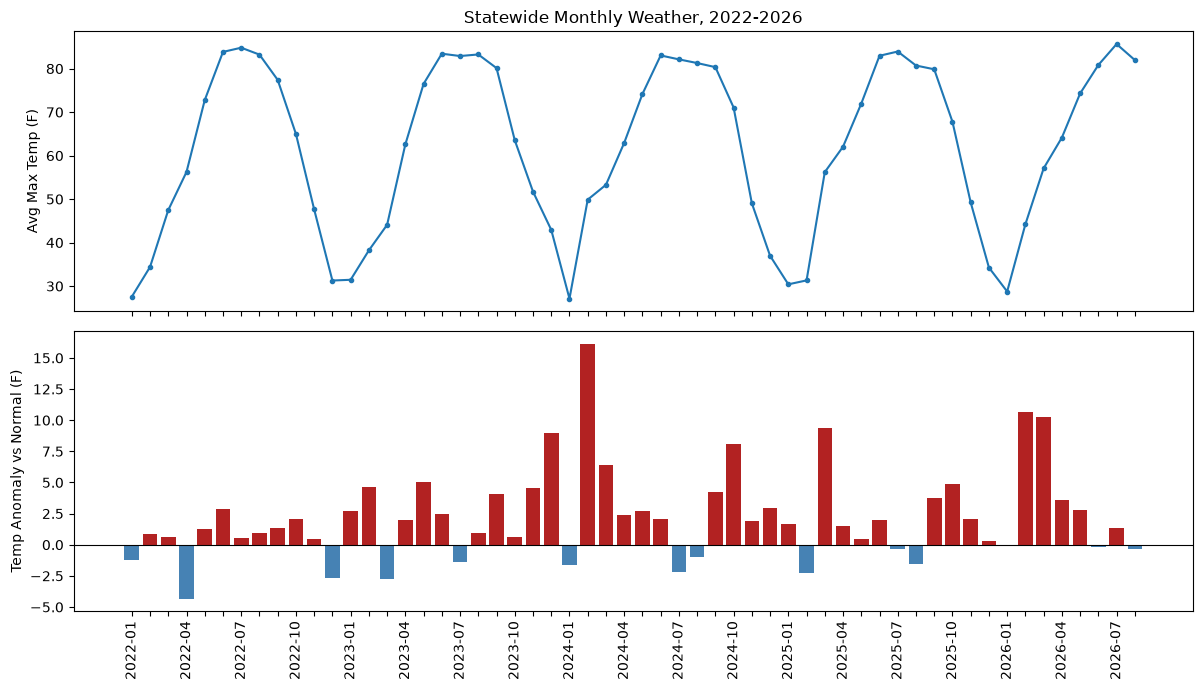

In [13]:
fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

axes[0].plot(monthly_weather["year_month"], monthly_weather["avg_max_temp_f"], marker="o", markersize=3)
axes[0].set_ylabel("Avg Max Temp (F)")
axes[0].set_title("Statewide Monthly Weather, 2022-2026")

axes[1].bar(monthly_weather["year_month"], monthly_weather["avg_temp_anomaly_f"],
            color=np.where(monthly_weather["avg_temp_anomaly_f"] >= 0, "firebrick", "steelblue"))
axes[1].axhline(0, color="black", linewidth=0.8)
axes[1].set_ylabel("Temp Anomaly vs Normal (F)")

for ax in axes:
    ax.tick_params(axis="x", rotation=90)
    for label in ax.get_xticklabels()[::3]:
        label.set_visible(True)
    for i, label in enumerate(ax.get_xticklabels()):
        if i % 3 != 0:
            label.set_visible(False)

plt.tight_layout()
plt.show()

### Merge weather onto the category x month panel, build the modeling table

Drops the blank `category_name` row (uncategorized/miscoded sales that don't
belong to any real product category, and would otherwise get their own
meaningless dummy column) and builds the linear time trend + month/category
dummy design matrix used by both models below.

In [14]:
df_weather = df.merge(monthly_weather, on="year_month", how="left")

print("rows before weather merge:", len(df))
print("rows with no weather match:", df_weather["avg_max_temp_f"].isna().sum())

df_weather = df_weather[df_weather["category_name"].str.strip() != ""].copy()

# rebuild the linear time trend + dummy design matrix now that weather columns exist
df_weather["t"] = (df_weather["year"] - df_weather["year"].min()) * 12 + df_weather["month_num"]

model_df = pd.get_dummies(
    df_weather,
    columns=["month_num", "category_name"],
    drop_first=True,
)

print(model_df.shape)
model_df.head()

rows before weather merge: 2474
rows with no weather match: 0
(2471, 81)


,year_month,year,total_units,total_dollars,total_liters,avg_bottle_price,realized_price_per_unit,n_stores,n_zips_reached,n_transactions,...,category_name_SINGLE MALT SCOTCH,category_name_SPECIAL ORDER ITEMS,category_name_SPICED RUM,category_name_STRAIGHT BOURBON WHISKIES,category_name_STRAIGHT RYE WHISKIES,category_name_TEMPORARY & SPECIALTY PACKAGES,category_name_TENNESSEE WHISKIES,category_name_TRIPLE SEC,category_name_WHISKEY LIQUEUR,category_name_WHITE RUM
3,2022-01,2022,50549.0,1443274.89,34750.75,NaN,28.551997,885,271,5596,...,False,False,False,False,False,False,False,False,False,False
4,2022-02,2022,63393.0,1927074.55,43229.90,NaN,30.398854,1004,281,6848,...,False,False,False,False,False,False,False,False,False,False
5,2022-03,2022,62335.0,1883096.29,44818.83,NaN,30.209293,1015,283,7561,...,False,False,False,False,False,False,False,False,False,False
6,2022-04,2022,85371.0,2380436.34,63738.14,NaN,27.883430,1062,289,8298,...,False,False,False,False,False,False,False,False,False,False
7,2022-05,2022,85112.0,2447897.91,65296.10,NaN,28.760902,1069,299,9047,...,False,False,False,False,False,False,False,False,False,False


### Model A — raw weather levels, no month fixed effects

Weather is left to explain seasonality on its own here (no month dummies).
This is the more intuitive model to describe to DEAD ("warmer months look
like this"), but note it can't distinguish a pure calendar effect from an
actual weather effect.

In [15]:
category_dummy_cols = [c for c in model_df.columns if c.startswith("category_name_")]

feature_cols_a = ["avg_max_temp_f", "total_precip_in", "t"] + category_dummy_cols
X_a = sm.add_constant(model_df[feature_cols_a].astype(float))
y = model_df["log_units"].astype(float)

model_a = sm.OLS(y, X_a, missing="drop").fit()
print(model_a.summary())

                            OLS Regression Results                            
Dep. Variable:              log_units   R-squared:                       0.956
Model:                            OLS   Adj. R-squared:                  0.955
Method:                 Least Squares   F-statistic:                     1001.
Date:                Sat, 12 Sep 2026   Prob (F-statistic):               0.00
Time:                        10:34:08   Log-Likelihood:                -911.82
No. Observations:                2471   AIC:                             1932.
Df Residuals:                    2417   BIC:                             2246.
Df Model:                          53                                         
Covariance Type:            nonrobust                                         
                                                         coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------

### Model B — weather *anomalies*, with month fixed effects (the rigorous test)

Now let month dummies soak up "what time of year is it," and ask whether a
month's temperature/precipitation being unusual *for that month* still
moves sales. This is the model that actually speaks to DEAD's hypothesis
("does weather drive purchases," as opposed to "does time of year").

In [16]:
month_dummy_cols = [c for c in model_df.columns if c.startswith("month_num_")]

feature_cols_b = ["avg_temp_anomaly_f", "total_precip_anomaly_in", "t"] + month_dummy_cols + category_dummy_cols
X_b = sm.add_constant(model_df[feature_cols_b].astype(float))

model_b = sm.OLS(y, X_b, missing="drop").fit()
print(model_b.summary())

                            OLS Regression Results                            
Dep. Variable:              log_units   R-squared:                       0.969
Model:                            OLS   Adj. R-squared:                  0.968
Method:                 Least Squares   F-statistic:                     1164.
Date:                Sat, 12 Sep 2026   Prob (F-statistic):               0.00
Time:                        10:34:08   Log-Likelihood:                -502.55
No. Observations:                2471   AIC:                             1135.
Df Residuals:                    2406   BIC:                             1513.
Df Model:                          64                                         
Covariance Type:            nonrobust                                         
                                                         coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------

In [17]:
comparison = pd.DataFrame({
    "Model A (raw weather, no month FE)": {
        "temp coef (per deg F)": model_a.params.get("avg_max_temp_f"),
        "temp p-value": model_a.pvalues.get("avg_max_temp_f"),
        "precip coef (per inch)": model_a.params.get("total_precip_in"),
        "precip p-value": model_a.pvalues.get("total_precip_in"),
        "R-squared": model_a.rsquared,
    },
    "Model B (temp/precip anomaly, +month FE)": {
        "temp coef (per deg F)": model_b.params.get("avg_temp_anomaly_f"),
        "temp p-value": model_b.pvalues.get("avg_temp_anomaly_f"),
        "precip coef (per inch)": model_b.params.get("total_precip_anomaly_in"),
        "precip p-value": model_b.pvalues.get("total_precip_anomaly_in"),
        "R-squared": model_b.rsquared,
    },
})
comparison

,"Model A (raw weather, no month FE)","Model B (temp/precip anomaly, +month FE)"
temp coef (per deg F),0.000037,-1.089617e-02
temp p-value,0.941464,6.629324e-08
precip coef (per inch),0.000590,2.299792e-03
precip p-value,0.912132,6.993247e-01
R-squared,0.956434,9.687187e-01


### Which categories move most with temperature?

A quick, model-free cut: correlate each category's month-to-month `log_units`
with that month's temperature anomaly, to see whether a warm-weather effect
(if any) concentrates in particular products (e.g. beer/RTD/tequila) rather
than liquor sales broadly.

In [18]:
category_temp_corr = (
    df_weather
    .groupby("category_name")[["log_units", "avg_temp_anomaly_f"]]
    .apply(lambda g: g["log_units"].corr(g["avg_temp_anomaly_f"]) if len(g) > 5 else np.nan)
    .dropna()
    .sort_values(ascending=False)
)

print("Most positively correlated with warm-anomaly months:")
print(category_temp_corr.head(10))
print()
print("Most negatively correlated with warm-anomaly months:")
print(category_temp_corr.tail(10))

Most positively correlated with warm-anomaly months:
category_name
IRISH WHISKIES                          0.046504
SINGLE BARREL BOURBON WHISKIES          0.030886
CREAM LIQUEURS                         -0.017754
IMPORTED DISTILLED SPIRITS SPECIALTY   -0.020481
FLAVORED GIN                           -0.026405
TEMPORARY & SPECIALTY PACKAGES         -0.047135
AMERICAN SCHNAPPS                      -0.049272
BOTTLED IN BOND BOURBON                -0.054395
100% AGAVE TEQUILA                     -0.064770
AMERICAN DISTILLED SPIRITS SPECIALTY   -0.067050
dtype: float64

Most negatively correlated with warm-anomaly months:
category_name
CORN WHISKIES                         -0.264039
AMERICAN FLAVORED VODKA               -0.277763
COCKTAILS/RTD                         -0.285572
IMPORTED DRY GINS                     -0.299333
IMPORTED CORDIALS & LIQUEUR           -0.312686
AMERICAN CORDIALS & LIQUEUR           -0.315064
WHITE RUM                             -0.333077
IMPORTED FLAVORED VODKA 

### Interpretation for DEAD

- **Model A** (raw weather, no seasonality control) will show a strong,
  "significant" temperature effect almost by construction — it's largely
  just re-detecting that summer sells more than winter. Useful for a plain
  "warmer months, more sales" chart, but not proof that weather itself is
  the driver.
- **Model B** (anomaly, with month fixed effects) is the harder test: it
  asks whether an *unusually* warm or wet month, relative to that month's
  own normal, still moves sales after controlling for which month it is.
  Look at `avg_temp_anomaly_f`'s coefficient, sign, and p-value in the
  summary above to see whether that survives.
- Caveat to give DEAD directly: this panel has 56 months and 52 categories,
  so month-to-month weather variation (temperature anomalies of a few
  degrees) is a much smaller signal than the enormous swing between, say,
  January and July, or the Nov/Dec holiday spike documented in
  `final_eda.ipynb`. A null or weak result on `avg_temp_anomaly_f` doesn't
  mean weather is irrelevant to drinking behavior generally — it means
  *month-to-month weather noise*, specifically, isn't a strong lever
  relative to calendar/holiday effects at this level of aggregation. If
  DEAD's real interest is short-term spikes (e.g. a heat wave weekend),
  that calls for the daily/zip-level data from `final_eda.ipynb` instead of
  this monthly panel.
- The category-level correlations above are a starting point for "does the
  weather effect concentrate somewhere" (e.g. patio/RTD drinks vs. spirits
  meant for cold-weather sipping) — worth a follow-up interaction model if
  DEAD wants to push on that specifically.

## Model evaluation — how good is this, really?

Sticking to linear regression as scoped, so "evaluating effectiveness" here
doesn't mean trying a random forest or GBM as a sanity check -- it means
being rigorous about what OLS itself can and can't tell us:

1. **Does weather actually earn its place in the model** (a formal nested
   F-test), or is the R-squared basically all coming from the month/category
   fixed effects regardless of weather?
2. **Do the regression's assumptions hold up** well enough to trust the
   p-values in the summary tables above (residual diagnostics)?
3. **Is there problematic multicollinearity** among the weather terms
   themselves (separate from the temp-vs-month-dummy issue already handled
   by using anomalies)?
4. **Does it generalize to months it hasn't seen** -- a time-based holdout,
   since in-sample R-squared of 0.95+ is easy to get here almost for free:
   52 category dummies alone will explain most of the variance, because
   knowing "this row is bourbon" vs "this row is RTD cocktails" predicts the
   scale of sales trivially well. That's not evidence weather matters.

### 1. Does weather earn its place? (nested F-test)

Fit a baseline model with everything Model B has *except* the weather
anomaly terms (trend + month FE + category FE), then test whether adding
`avg_temp_anomaly_f` and `total_precip_anomaly_in` produces a statistically
significant improvement in fit, not just a numerically bigger R-squared.

In [19]:
feature_cols_baseline = ["t"] + month_dummy_cols + category_dummy_cols
X_baseline = sm.add_constant(model_df[feature_cols_baseline].astype(float))

model_baseline = sm.OLS(y, X_baseline, missing="drop").fit()

anova_result = sm.stats.anova_lm(model_baseline, model_b)
print(anova_result)

fit_comparison = pd.DataFrame({
    "Baseline (no weather)": {
        "adj. R-squared": model_baseline.rsquared_adj,
        "AIC": model_baseline.aic,
        "BIC": model_baseline.bic,
    },
    "Model B (+ weather anomalies)": {
        "adj. R-squared": model_b.rsquared_adj,
        "AIC": model_b.aic,
        "BIC": model_b.bic,
    },
})
fit_comparison

   df_resid         ssr  df_diff   ss_diff          F        Pr(>F)
0    2408.0  220.001543      0.0       NaN        NaN           NaN
1    2406.0  217.295087      2.0  2.706457  14.983622  3.411044e-07


,Baseline (no weather),Model B (+ weather anomalies)
adj. R-squared,0.967514,0.967887
AIC,1161.678686,1135.091943
BIC,1527.858513,1512.896527


A significant F-test (small `Pr(>F)`) means weather is pulling its
weight beyond the fixed effects already in the model. Lower AIC/BIC for
Model B (both penalize extra parameters, unlike raw R-squared) is the same
check from a different angle -- it's possible for weather to be
"significant" by the F-test while barely moving AIC/BIC if the effect size
is tiny relative to the added complexity, so look at both.

### 2. Residual diagnostics (on Model B)

The p-values above are only trustworthy if OLS's assumptions roughly hold:
linear relationship, homoskedastic (constant-variance) errors, and
roughly-normal residuals. Checked visually and with a couple of formal
tests.

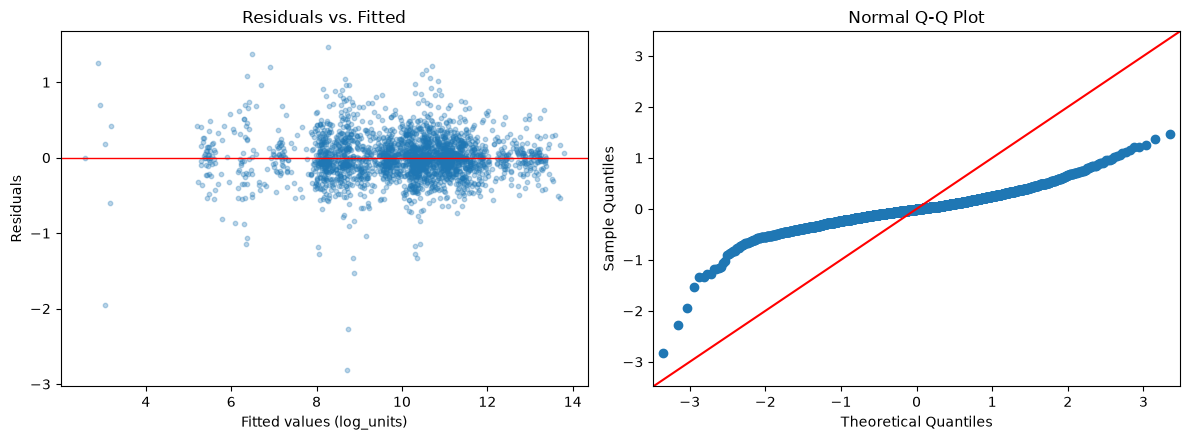

Breusch-Pagan test for heteroskedasticity: stat=560.06, p=2.414e-80
(p < 0.05 means the constant-variance assumption is violated -- common with count-like sales data even after log-transforming)

Durbin-Watson (from the Model B summary table above): 1.145
(~2.0 = no autocorrelation; well below 2 -- expected here, since each category's 56 monthly observations are a time series and likely correlated with themselves month-to-month, which OLS's standard errors don't account for. Worth flagging to DEAD: this doesn't bias the coefficients, but it does mean the p-values above are probably a bit optimistic -- a clustered or Newey-West standard error would be the fix if this were the final deliverable.)


In [20]:
from statsmodels.graphics.gofplots import qqplot
from statsmodels.stats.diagnostic import het_breuschpagan

resid = model_b.resid
fitted = model_b.fittedvalues

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].scatter(fitted, resid, alpha=0.3, s=10)
axes[0].axhline(0, color="red", linewidth=1)
axes[0].set_xlabel("Fitted values (log_units)")
axes[0].set_ylabel("Residuals")
axes[0].set_title("Residuals vs. Fitted")

qqplot(resid, line="45", ax=axes[1])
axes[1].set_title("Normal Q-Q Plot")

plt.tight_layout()
plt.show()

bp_stat, bp_pvalue, _, _ = het_breuschpagan(resid, model_b.model.exog)
print(f"Breusch-Pagan test for heteroskedasticity: stat={bp_stat:.2f}, p={bp_pvalue:.4g}")
print(f"(p < 0.05 means the constant-variance assumption is violated -- "
      f"common with count-like sales data even after log-transforming)")
print()
print(f"Durbin-Watson (from the Model B summary table above): "
      f"{sm.stats.stattools.durbin_watson(resid):.3f}")
print("(~2.0 = no autocorrelation; well below 2 -- expected here, since each "
      "category's 56 monthly observations are a time series and likely "
      "correlated with themselves month-to-month, which OLS's standard "
      "errors don't account for. Worth flagging to DEAD: this doesn't bias "
      "the coefficients, but it does mean the p-values above are probably "
      "a bit optimistic -- a clustered or Newey-West standard error would "
      "be the fix if this were the final deliverable.)")

### 3. Multicollinearity among the weather terms

Already addressed the big collinearity issue (temperature vs. month) by
using anomalies instead of raw levels. Worth also checking the anomaly
terms and trend aren't collinear with *each other* (VIF > ~5-10 would be a
concern; below that is fine).

In [21]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif_check_cols = ["avg_temp_anomaly_f", "total_precip_anomaly_in", "t"]
X_vif = sm.add_constant(model_df[feature_cols_b].astype(float))

vif_scores = pd.Series(
    [variance_inflation_factor(X_vif.values, X_vif.columns.get_loc(c)) for c in vif_check_cols],
    index=vif_check_cols,
    name="VIF",
)
vif_scores

avg_temp_anomaly_f         1.508803
total_precip_anomaly_in    1.470099
t                          1.219878
Name: VIF, dtype: float64

### 4. Does it generalize? (time-based holdout)

In-sample R-squared can't tell you whether a model would have been useful
for predicting a month it didn't see. Since this is a time panel, the
holdout has to be the **most recent months**, not a random sample --
randomly held-out rows would let the category/month fixed effects "cheat"
by having already seen every category and most months in training.

In [22]:
HOLDOUT_MONTHS = 6  # most recent 6 year-months held out for testing

all_year_months = sorted(model_df["year_month"].unique())
test_months = all_year_months[-HOLDOUT_MONTHS:]
train_mask = ~model_df["year_month"].isin(test_months)
test_mask = model_df["year_month"].isin(test_months)

print(f"Training on {train_mask.sum()} rows through {all_year_months[-HOLDOUT_MONTHS - 1]}, "
      f"testing on {test_mask.sum()} rows from {test_months[0]} to {test_months[-1]}")


def fit_and_evaluate(feature_cols, label):
    X_train = sm.add_constant(model_df.loc[train_mask, feature_cols].astype(float))
    y_train = model_df.loc[train_mask, "log_units"].astype(float)
    fitted_model = sm.OLS(y_train, X_train, missing="drop").fit()

    X_test = sm.add_constant(model_df.loc[test_mask, feature_cols].astype(float), has_constant="add")
    X_test = X_test.reindex(columns=X_train.columns, fill_value=0.0)
    y_test = model_df.loc[test_mask, "log_units"].astype(float)
    preds = fitted_model.predict(X_test)

    rmse_log = np.sqrt(np.mean((preds - y_test) ** 2))
    mae_log = np.mean(np.abs(preds - y_test))

    # back-transform to real units (undo the log1p from the target-prep step) for an
    # interpretable error -- "off by how many bottles/liters," not "off by how much log"
    actual_units = np.expm1(y_test)
    pred_units = np.expm1(preds)
    rmse_units = np.sqrt(np.mean((pred_units - actual_units) ** 2))
    mae_units = np.mean(np.abs(pred_units - actual_units))

    return {
        "in-sample adj. R2": fitted_model.rsquared_adj,
        "holdout RMSE (log)": rmse_log,
        "holdout MAE (log)": mae_log,
        "holdout RMSE (units)": rmse_units,
        "holdout MAE (units)": mae_units,
    }


holdout_results = pd.DataFrame({
    "Baseline (no weather)": fit_and_evaluate(feature_cols_baseline, "baseline"),
    "Model A (raw weather, no month FE)": fit_and_evaluate(
        ["avg_max_temp_f", "total_precip_in", "t"] + category_dummy_cols, "A"
    ),
    "Model B (anomaly + month FE)": fit_and_evaluate(feature_cols_b, "B"),
}).T

holdout_results

Training on 2207 rows through 2026-02, testing on 264 rows from 2026-03 to 2026-08


,in-sample adj. R2,holdout RMSE (log),holdout MAE (log),holdout RMSE (units),holdout MAE (units)
Baseline (no weather),0.970463,0.445493,0.331824,67176.837952,22728.635774
"Model A (raw weather, no month FE)",0.957202,0.427067,0.329119,62527.831073,20815.124789
Model B (anomaly + month FE),0.970858,0.445149,0.333573,66883.181440,22771.416565


### What this means for DEAD

- The **nested F-test** is the honest answer to "does weather matter": a
  significant result there means weather anomalies improve the fit beyond
  what calendar month and product category already explain -- a null result
  means, at this monthly/statewide grain, weather noise isn't doing
  meaningful work once you already know the month.
- The **holdout comparison** is the honest answer to "would this have been
  useful going forward": compare each model's holdout RMSE/MAE against the
  baseline's. If Model B's holdout error isn't meaningfully better than the
  no-weather baseline, that's a stronger and more useful statement to give
  DEAD than the in-sample R-squared, which will look impressive (0.95+) for
  every version of this model because of the category fixed effects alone.
- The **diagnostics** are about honesty regarding uncertainty, not about
  whether to trust the point estimates: the Breusch-Pagan/Durbin-Watson
  results here are typical for monthly sales panels and mean the standard
  errors (and therefore the p-values) are probably somewhat optimistic --
  worth a caveat in anything handed to DEAD, not a reason to throw out the
  model.
- None of this changes the earlier finding that month-to-month weather
  variation is a small signal next to the Jan-vs-July and holiday swings
  already documented -- this section is about whether that small signal is
  *real* (survives a fair test) and *useful* (survives a holdout), not about
  making it bigger.